## Analiza danych kliniki weterynaryjnej oraz modele uczenia maszynowego
Niniejszy notebook przedstawia proces analizy danych pochodzących z kliniki weterynaryjnej. Projekt obejmuje integrację danych z relacyjnej bazy danych SQL, analizę eksploracyjną, wizualizację danych oraz budowę modeli uczenia maszynowego.

Główne cele projektu:
- analiza wizyt, zabiegów, recept, pacjentów oraz lekarzy weterynarii,
- identyfikacja zależności pomiędzy cechami zabiegów a ich kosztami,
- predykcja kosztu zabiegu przy użyciu modeli regresyjnych,
- klasyfikacja zabiegów na kosztowne i niekosztowne,
- porównanie skuteczności różnych modeli uczenia maszynowego.

In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
owners = pd.read_csv('Owners.csv', sep=';')
pets = pd.read_csv('Pets.csv', sep=';')
vets = pd.read_csv('Vets.csv', sep=';')
visits = pd.read_csv('Visits.csv', sep=';')
treatments = pd.read_csv('Treatments.csv', sep=';')
prescriptions = pd.read_csv('Prescriptions.csv', sep=';')

In [133]:
pets.head()

,animal_id,name,species,breed,birth_date,weight,gender,owner_id
0,1,Rex,pies,labrador,2020-05-10,30.5,samiec,1
1,2,Mruczek,kot,dachowiec,NaN,4.2,samiec,2
2,3,Bella,pies,buldog,2023-04-01,12.0,samica,1
3,4,Kropka,kot,perski,2019-11-05,3.8,samica,3
4,5,Kruszynka,chomik,NaN,NaN,NaN,samica,4


In [134]:
# budowa jednej tabeli analitycznej
df = visits.merge(pets, on='animal_id', how='left')
df = df.merge(treatments, on='visit_id', how='left')
df = df.merge(vets, on='vet_id', how='left')
df = df.merge(owners, on='owner_id', how='left')

In [135]:
df

,visit_id,animal_id,vet_id,visit_date,reason,notes_x,status,name_x,species,breed,...,specialization,phone_x,hire_date,first_name_y,last_name_y,phone_y,email,city,street,postal_code
0,1,1,5.0,2025-04-10 10:00:00.000,szczepienie,brak uwag,zakończona,Rex,pies,labrador,...,asystent weterynarii,755688717.0,2019-11-05,Jan,Kowalski,123456789,jan@gmail.com,Kraków,ul. Długa 10,30-011
1,2,2,2.0,2025-04-11 12:00:00.000,alergia,wysypka na skórze,zakończona,Mruczek,kot,dachowiec,...,dermatologia,324855166.0,2020-06-15,Anna,Nowak,987654321,anna@gmail.com,Katowice,ul. Znajoma 5,40-002
2,3,3,1.0,2025-04-15 09:00:00.000,kontrola,NaN,zakończona,Bella,pies,buldog,...,chirurgia,791227333.0,2015-03-01,Jan,Kowalski,123456789,jan@gmail.com,Kraków,ul. Długa 10,30-011
3,4,4,3.0,2025-04-16 11:00:00.000,uraz łapy,lekkie kulawienie,zakończona,Kropka,kot,perski,...,ortopedia,127883919.0,2018-09-10,Piotr,Zieliński,222111333,NaN,Kraków,ul. Szeroka 8,30-111
4,5,5,1.0,2025-05-16 13:00:00.000,operacja,usunięcie guza,zakończona,Kruszynka,chomik,NaN,...,chirurgia,791227333.0,2015-03-01,Marzena,Mazur,987654311,m.mazur12@wp.pl,Niepołomice,ul. Polna 15,35-102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,182,70,6.0,2025-08-26 10:30:00.000,kardiologia,kontrola leczenia farmakologicznego,zaplanowana,Pępek,królik,NaN,...,kardiologia,744628788.0,2018-10-15,Halina,Kamińska,620202020,NaN,Kraków,ul. Opolska 22,31-323
182,183,73,4.0,2025-08-27 09:00:00.000,diagnostyka,planowane badanie biochemiczne krwi,zaplanowana,Leon,pies,owczarek niemiecki,...,radiologia,772333444.0,2019-01-20,Dorota,Pietrzak,613131313,NaN,Kraków,ul. Łagiewnicka 55,30-417
183,184,74,1.0,2025-08-27 11:00:00.000,kontrola po operacji,usunięcie szwów po zabiegu,zaplanowana,Koko,papuga,NaN,...,chirurgia,791227333.0,2015-03-01,Wojciech,Grabowski,614141414,w.grabowski@onet.pl,Nowy Targ,ul. Waksmundzka 2,34-400
184,185,76,5.0,2025-08-28 09:00:00.000,szczepienie,szczepienie przypominające,zaplanowana,Rufi,pies,beagle,...,asystent weterynarii,755688717.0,2019-11-05,Sławomir,Czarnecki,616161616,NaN,Chrzanów,ul. Kusocińskiego 4,32-500


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   visit_id        186 non-null    int64  
 1   animal_id       186 non-null    int64  
 2   vet_id          178 non-null    float64
 3   visit_date      186 non-null    object 
 4   reason          186 non-null    object 
 5   notes_x         166 non-null    object 
 6   status          186 non-null    object 
 7   name_x          186 non-null    object 
 8   species         186 non-null    object 
 9   breed           153 non-null    object 
 10  birth_date      153 non-null    object 
 11  weight          183 non-null    float64
 12  gender          186 non-null    object 
 13  owner_id        186 non-null    int64  
 14  treatment_id    147 non-null    float64
 15  name_y          147 non-null    object 
 16  description     147 non-null    object 
 17  notes_y         146 non-null    obj

In [137]:
df.describe()

,visit_id,animal_id,vet_id,weight,owner_id,treatment_id,duration,cost,phone_x,phone_y
count,186.000000,186.00000,178.000000,183.000000,186.000000,147.000000,147.000000,147.000000,1.780000e+02,1.860000e+02
mean,93.500000,39.55914,3.370787,12.620219,15.559140,74.000000,37.448980,102.959184,6.025731e+08,5.799011e+08
std,53.837719,22.90826,1.758800,14.873806,9.004458,42.579338,23.352329,129.165863,2.576303e+08,2.152313e+08
min,1.000000,1.00000,1.000000,0.280000,1.000000,1.000000,15.000000,15.000000,1.278839e+08,1.212543e+08
25%,47.250000,19.25000,2.000000,3.700000,7.000000,37.500000,25.000000,55.000000,3.248552e+08,6.033334e+08
50%,93.500000,40.00000,3.000000,5.000000,16.000000,74.000000,30.000000,70.000000,7.556887e+08,6.121212e+08
75%,139.750000,59.75000,5.000000,18.000000,24.000000,110.500000,40.000000,100.000000,7.723334e+08,6.181818e+08
max,186.000000,78.00000,6.000000,72.000000,30.000000,147.000000,180.000000,1200.000000,7.912273e+08,9.876543e+08


In [138]:
df.isnull().sum()

,0
visit_id,0
animal_id,0
vet_id,8
visit_date,0
reason,0
notes_x,20
status,0
name_x,0
species,0
breed,33


In [139]:
print("Łączny przychód:", df['cost'].sum())
print("Średni koszt zabiegu:", df['cost'].mean())
print("Liczba odbytych zabiegów:", df['treatment_id'].nunique())
print("Liczba zwierząt:", df['animal_id'].nunique())

Łączny przychód: 15135.0
Średni koszt zabiegu: 102.95918367346938
Liczba odbytych zabiegów: 147
Liczba zwierząt: 78


## Analiza eksploracyjna

In [140]:
# analiza kategorii leczenia
df.groupby('name_y')['cost'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False)

,count,sum,mean
name_y,,,
chirurgia,14,4180.0,298.571429
kardiologia,18,2420.0,134.444444
ortopedia,18,1840.0,102.222222
diagnostyka,15,1625.0,108.333333
dermatologia,22,1615.0,73.409091
badanie ogólne,18,1075.0,59.722222
szczepienie,16,970.0,60.625000
kontrola,10,390.0,39.000000
odrobaczanie,6,205.0,34.166667


In [141]:
# analiza lekarzy
df['vet_fullName'] = df['first_name_x'] + ' ' + df['last_name_x']
df.groupby('vet_fullName')['cost'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False)

,count,sum,mean
vet_fullName,,,
Marek Nowak,31,4175.0,134.677419
Tomasz Kaczmarek,25,3260.0,130.400000
Ewa Lis,25,2170.0,86.800000
Paweł Mazur,27,2130.0,78.888889
Janusz Szymański,19,1990.0,104.736842
Anna Wójcik,20,1410.0,70.500000


In [142]:
# analiza gatunków
df.groupby('species')['cost'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False)

,count,sum,mean
species,,,
pies,71,7340.0,103.380282
kot,52,4775.0,91.826923
chomik,11,1240.0,112.727273
królik,6,1150.0,191.666667
papuga,7,630.0,90.000000


In [143]:
# analiza top 10 pacjentów
df.groupby('name_x')['cost'].agg(['count','sum','mean']).sort_values(by='sum',ascending=False).head(10)

,count,sum,mean
name_x,,,
Ptyś,2,1250.0,625.000000
Puch,2,940.0,470.000000
Czesia,2,485.0,242.500000
Loki,2,415.0,207.500000
Atlas,2,390.0,195.000000
Pistacjo,2,380.0,190.000000
Kleks,2,360.0,180.000000
Zuzia,3,335.0,111.666667
Śmiga,2,325.0,162.500000


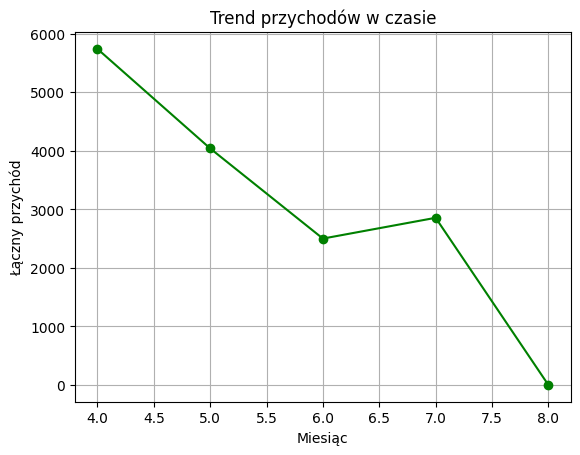

In [144]:
# przychów w poszczególnych miesiącu
df['visit_date'] = pd.to_datetime(df['visit_date'])
df.groupby(df['visit_date'].dt.month)['cost'].sum().plot(kind='line',marker='o', color='g')
plt.title('Trend przychodów w czasie')
plt.xlabel('Miesiąc')
plt.ylabel('Łączny przychód')
plt.grid()
plt.show()

In [145]:
# analiza statusów wizyt
df['status'].value_counts()

,count
status,
zakończona,147
zaplanowana,32
anulowana,7


In [146]:
df['status'].value_counts(normalize=True) * 100

,proportion
status,
zakończona,79.032258
zaplanowana,17.204301
anulowana,3.763441


- Wizyty zakończone w klinice wynoszą około 79%, zaplanowanych jest 17.20%, a anulowanych niespełna 3.80%.

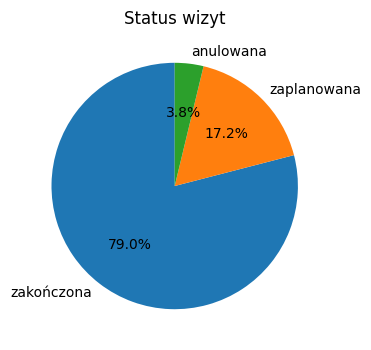

In [147]:
plt.figure(figsize=(6, 4))
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Status wizyt')
plt.show()

In [148]:
# liczba wizyt według gatunku
df.groupby('species')['treatment_id'].count().sort_values(ascending=False)

,treatment_id
species,
pies,71
kot,52
chomik,11
papuga,7
królik,6


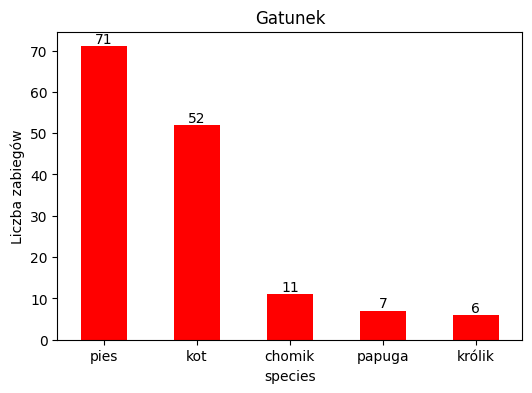

In [149]:
plt.figure(figsize=(6, 4))
data = df.groupby('species')['treatment_id'].count().sort_values(ascending=False)
ax = data.plot(kind='bar',color='r')
plt.ylabel('Liczba zabiegów')
plt.title('Gatunek')
plt.xticks(rotation=0)

for i, v in enumerate(data):
  ax.text(i,v + max(data)*0.01, str(v), ha='center')

plt.show()

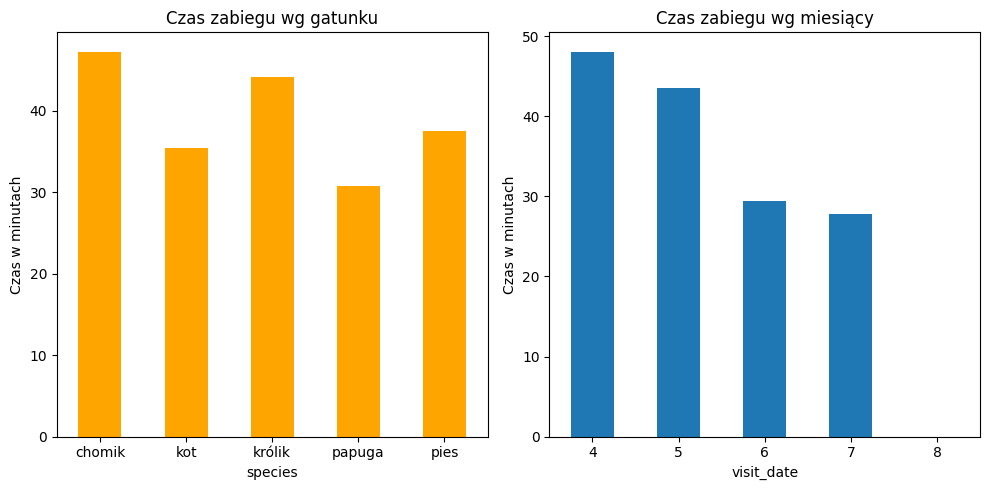

In [150]:
# czas zabiegu według miesięcy i gatunków
fig, ax = plt.subplots(1, 2, figsize=(10,5))

df.groupby('species')['duration'].mean().plot(kind='bar', ax=ax[0], color='orange', rot=0)
ax[0].set_title('Czas zabiegu wg gatunku')
ax[0].set_ylabel('Czas w minutach')

df.groupby(df['visit_date'].dt.month)['duration'].mean().plot(kind='bar', ax=ax[1], rot=0)
ax[1].set_title('Czas zabiegu wg miesiący')
ax[1].set_ylabel('Czas w minutach')
plt.tight_layout()
plt.show()

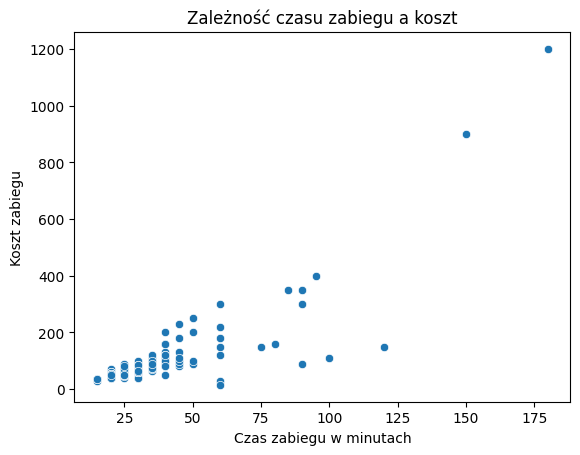

In [151]:
# czas według kosztu
sns.scatterplot(data=df, x='duration', y='cost')

plt.title('Zależność czasu zabiegu a koszt')
plt.xlabel('Czas zabiegu w minutach')
plt.ylabel('Koszt zabiegu')
plt.show()

Wnioski z wykresu:
- Na wykresie widoczna jest silna dodatnia zależność między czasem trwania zabiegu a jego kosztem. Wraz ze wzrostem czasu zabiegu rośnie również jego cena.
- Większość zabiegów trwa od około 20 do 60 minut i kosztuje w okolicach od 30 do 250 zł, co wskazuje na dominację standardowych procedur wykonywanych w klinice.
- Widoczne są pojedyncze bardzo kosztowne i długotrwałe zabiegi około 150-180 minut i 900-1200 zł. Są to prawdopodobnie zabiegi specjalistyczne lub operacyjne.

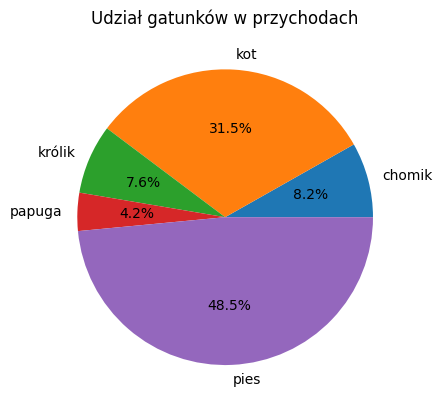

In [152]:
# który gatunek generuje najwięcej przychodu
df.groupby('species')['cost'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Udział gatunków w przychodach')
plt.ylabel('')
plt.show()

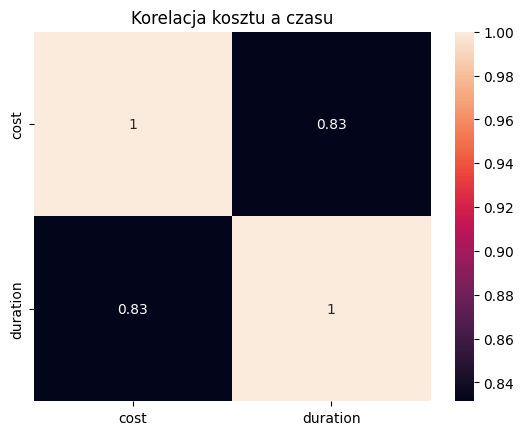

In [153]:
corr = df[['cost','duration']].corr()
sns.heatmap(corr, annot=True)
plt.title('Korelacja kosztu a czasu')
plt.show()

Wnioski:
- Współczynnik korelacji pomiędzy kosztem a czasem zabiegu wynosi 0.8314, co oznacza silną dodatnią korelację. Oznacza to, że dłuższe zabiegi są zazwyczaj droższe,
a czas trwania zabiegu jest jednym z najważniejszych czynników wpływających na koszt leczenia.
- Wartość korelacji powyżej 0.8 wskazuje na bardzo wyraźną zależność liniową między analizowanymi zmiennymi. Zależność ta sugeruje, że zmienna duration może być bardzo dobrym predyktorem w modelu uczenia maszynowego służącym do przewidywania kosztu zabiegu.

In [154]:
# analiza leków
df_prescriptions = df.merge(prescriptions, on = 'treatment_id', how='left')

In [155]:
# najczęściej przepisywane leki
df_prescriptions['medicine_name'].value_counts()

,count
medicine_name,
Metacam,5
Meloksykam,3
Furosemid 20 mg,3
Metacam 1.5 mg/ml,3
Amoksycylina 250 mg,2
Sotalol 40 mg,2
Cosequin DS,2
Amoksycylina 500 mg,2
Malaseb szampon,2


In [156]:
# średni czas leczenia dla leków
df_prescriptions.groupby('medicine_name')['duration_days'].mean().sort_values(ascending=False)

,duration_days
medicine_name,
Cosequin DS,75.0
Urinary S/O karma,60.0
Royal Canin Satiety,60.0
Atenolol 12.5 mg,30.0
Furosemid 10 mg,30.0
Furosemid 20 mg,30.0
Royal Canin Hypoallergenic,30.0
Vetmedin 1.25 mg,30.0
Atenolol 25 mg,30.0


In [157]:
# jakie gatunki najczęściej otrzymują leki
df_prescriptions.groupby('species')['prescription_id'].count().sort_values(ascending=False)

,prescription_id
species,
pies,28
kot,18
chomik,11
królik,3
papuga,0


In [158]:
# jakie zabiegi najczęściej kończą się receptą
df_prescriptions.groupby('name_y')['prescription_id'].count().sort_values(ascending=False)

,prescription_id
name_y,
dermatologia,9
badanie ogólne,8
ortopedia,7
chirurgia,7
szczepienie,7
kontrola,5
uraz łapy,3
kardiologia,3
odrobaczanie,3


Udział zabiegów zakończonych wystawieniem recepty

In [159]:
# liczba recept dla zabiegów
recepty = (df_prescriptions.groupby('name_y')['prescription_id'].count().reset_index(name='liczba_recept'))
recepty

,name_y,liczba_recept
0,alergia,1
1,badanie ogólne,8
2,chirurgia,7
3,dermatologia,9
4,diagnostyka,2
5,dieta,0
6,kardiologia,3
7,kontrola,5
8,kontrola ortopedyczna,0
9,kontrola pooperacyjna,1


In [160]:
# liczba wszystkich wykonanych zabiegów
zabiegi = (df_prescriptions.groupby('name_y')['treatment_id'].count().reset_index(name='liczba_zabiegów'))
zabiegi

,name_y,liczba_zabiegów
0,alergia,2
1,badanie ogólne,20
2,chirurgia,17
3,dermatologia,26
4,diagnostyka,15
5,dieta,1
6,kardiologia,19
7,kontrola,13
8,kontrola ortopedyczna,1
9,kontrola pooperacyjna,1


In [161]:
analiza = recepty.merge(zabiegi, on='name_y', how='left')
analiza.head()

,name_y,liczba_recept,liczba_zabiegów
0,alergia,1,2
1,badanie ogólne,8,20
2,chirurgia,7,17
3,dermatologia,9,26
4,diagnostyka,2,15


In [162]:
# procent udziału recepty w wykonanych zabiegach
analiza['procent_recept'] = (analiza['liczba_recept'] / analiza['liczba_zabiegów']) * 100
analiza

,name_y,liczba_recept,liczba_zabiegów,procent_recept
0,alergia,1,2,50.000000
1,badanie ogólne,8,20,40.000000
2,chirurgia,7,17,41.176471
3,dermatologia,9,26,34.615385
4,diagnostyka,2,15,13.333333
5,dieta,0,1,0.000000
6,kardiologia,3,19,15.789474
7,kontrola,5,13,38.461538
8,kontrola ortopedyczna,0,1,0.000000
9,kontrola pooperacyjna,1,1,100.000000


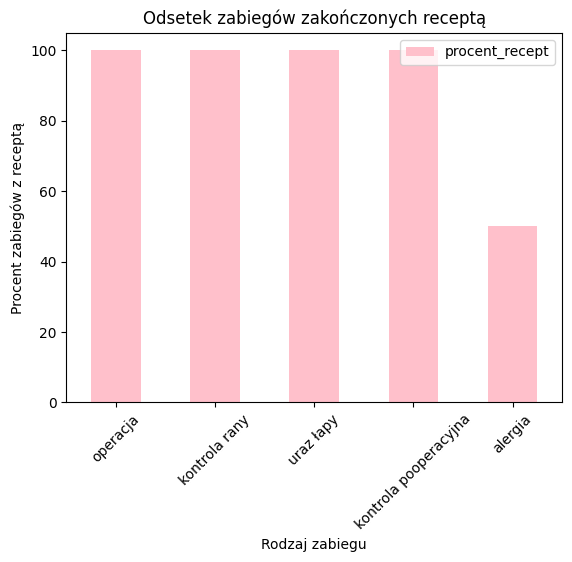

In [163]:
analiza.sort_values(by='procent_recept', ascending=False).head(5).plot(x='name_y', y='procent_recept',kind='bar', color='pink')

plt.title('Odsetek zabiegów zakończonych receptą')
plt.xlabel('Rodzaj zabiegu')
plt.ylabel('Procent zabiegów z receptą')
plt.xticks(rotation=45)
plt.show()

## Uczenie maszynowe - predykcja kosztu zabiegu, zastosowanie regresji, czyli wartości liczbowej.

Algorytmy: LinearRegression, Random Forest, XGBoost

In [164]:
# filtrowanie kolumn - usunięcie wizyt zaplanowanych i anulowanych, ponieważ nie zawierają informacji o rzeczywistym koszcie zabiegu
df_ml = df[(df['status'] == 'zakończona') & (df['cost'].notna())].copy()

In [165]:
df_ml['status']

,status
0,zakończona
1,zakończona
2,zakończona
3,zakończona
4,zakończona
...,...
149,zakończona
150,zakończona
151,zakończona
152,zakończona


In [166]:
df_ml[['duration','species','gender','cost']].isna().sum()

,0
duration,0
species,0
gender,0
cost,0


In [167]:
X = df_ml[['duration','species','gender']]
y = df_ml['cost']

In [168]:
y

,cost
0,50.0
1,40.0
2,30.0
3,90.0
4,150.0
...,...
149,90.0
150,80.0
151,65.0
152,50.0


In [169]:
X

,duration,species,gender
0,40.0,pies,samiec
1,30.0,kot,samiec
2,60.0,pies,samica
3,90.0,kot,samica
4,120.0,chomik,samica
...,...,...,...
149,35.0,pies,samiec
150,25.0,papuga,samica
151,30.0,kot,samica
152,20.0,pies,samiec


In [170]:
# kodowanie danych tekstowych
X = pd.get_dummies(X, columns=['species','gender'], drop_first=True)
X

,duration,species_kot,species_królik,species_papuga,species_pies,gender_samica,gender_samiec
0,40.0,False,False,False,True,False,True
1,30.0,True,False,False,False,False,True
2,60.0,False,False,False,True,True,False
3,90.0,True,False,False,False,True,False
4,120.0,False,False,False,False,True,False
...,...,...,...,...,...,...,...
149,35.0,False,False,False,True,False,True
150,25.0,False,False,True,False,True,False
151,30.0,True,False,False,False,True,False
152,20.0,False,False,False,True,False,True


In [171]:
# podział - zbiór treningowy i testowy
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [172]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((117, 7), (30, 7), (117,), (30,))

## Model - regresja liniowa

In [173]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [174]:
y_pred

array([135.70554857,  43.35667792,  31.26484616,  31.26484616,
        66.44389558,  89.53111324,  77.43928149,  14.72673014,
       135.70554857,  20.26946026,  -2.8177574 ,  30.2085242 ,
        58.22371904, 104.68423872,  37.8139478 ,  60.90116546,
       138.76684229,  58.22371904,  -2.8177574 , 320.40328986,
       122.55739485,  89.53111324,  60.90116546,  76.38295953,
       112.61833091, 100.52649915, 130.16281844,  54.35206383,
        31.26484616, 107.07560078])

In [175]:
from sklearn.metrics import mean_absolute_error, r2_score

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.6638753284180363
MAE: 29.07235305051106


Wnioski:
- Model regresji liniowej osiągnął współczynnik determinacji R2 na poziomie 0.664, co oznacza, że wyjaśnia około 66,4% zmienności kosztów zabiegów.
Średni błąd bezwzględny wyniósł około 29.07 zł, co oznacza, że przewidywana wartość kosztu różniła się od rzeczywistej średnio o około 29 zł.
Wyniki wskazują na umiarkowanie dobrą skuteczność modelu i potwierdzają, że wykorzystane cechy, w szczególności czas trwania zabiegu, mają istotny wpływ na jego koszt.

In [176]:
# porównanie rzeczywiste vs przewidywane
porownanie = pd.DataFrame({'Rzeczywisty koszt': y_test, 'Przewidywany koszt' :y_pred})
porownanie

porownanie['Błąd bezwzględny'] = abs(porownanie['Rzeczywisty koszt'] - porownanie['Przewidywany koszt'])
porownanie

,Rzeczywisty koszt,Przewidywany koszt,Błąd bezwzględny
132,230.0,135.705549,94.294451
53,70.0,43.356678,26.643322
145,50.0,31.264846,18.735154
21,50.0,31.264846,18.735154
111,65.0,66.443896,1.443896
14,85.0,89.531113,4.531113
83,110.0,77.439281,32.560719
33,40.0,14.726730,25.273270
88,110.0,135.705549,25.705549
11,70.0,20.269460,49.730540


## Model 2 - RandomForest

In [177]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,max_depth=5,random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [178]:
y_pred_rf

array([110.3011952 ,  54.0909114 ,  60.4127184 ,  60.4127184 ,
        62.83631108,  93.10432148,  94.32299018,  52.27164203,
       110.3011952 ,  46.22248603,  37.43498161,  64.30019964,
        62.66793196,  63.06299634,  65.83343764,  70.46055675,
        86.95248029,  62.66793196,  37.43498161, 173.07876837,
       197.70422949,  93.10432148,  70.46055675, 104.82325242,
       105.23596797,  97.76033083,  93.76281404,  68.03644629,
        60.4127184 ,  93.85887132])

In [179]:
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2: 0.4368537729715374
MAE: 27.409963627102215


## Strojenie parametrów

In [180]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Najlepsze parametry:", grid.best_params_)
print("Najlepszy wynik:", grid.best_score_)

Najlepsze parametry: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Najlepszy wynik: 0.2989287414586954


In [181]:
best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_best_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_best_rf))

R2: 0.4726375683691506
MAE: 26.518747106638404


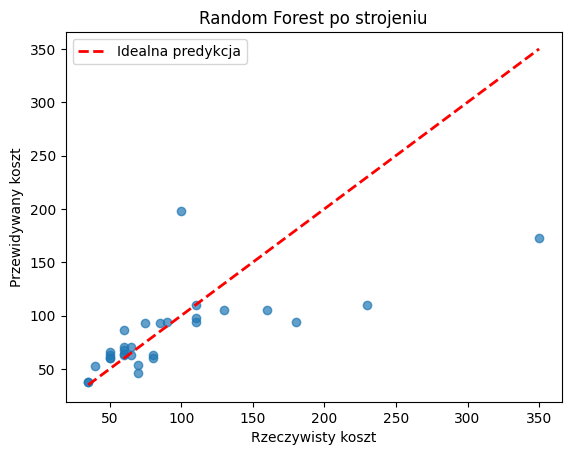

In [182]:
plt.scatter(y_test, y_pred_rf, alpha=0.7)

# linia idealnego dopasowania y=x
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot([min_val, max_val], [min_val, max_val],'r--',linewidth=2, label='Idealna predykcja')
plt.xlabel('Rzeczywisty koszt')
plt.ylabel('Przewidywany koszt')
plt.title('Random Forest po strojeniu')
plt.legend()
plt.show()

In [183]:
porownanie_rf = pd.DataFrame({'Rzeczywisty koszt': y_test, 'Przewidywany koszt' :y_pred_best_rf})
porownanie_rf['Błąd bezwzględny'] = abs(porownanie_rf['Rzeczywisty koszt'] - porownanie_rf['Przewidywany koszt'])
porownanie_rf.head()

,Rzeczywisty koszt,Przewidywany koszt,Błąd bezwzględny
132,230.0,111.520484,118.479516
53,70.0,53.798795,16.201205
145,50.0,60.151909,10.151909
21,50.0,60.151909,10.151909
111,65.0,62.558989,2.441011


Wnioski
- Model przed strojeniem uzyskał R2 = 0.437, czyli wyjaśnia około 43.7% zmienności kosztów zabiegów. Natomiast po strojeniu R2 = 0.473, model wyjaśnia około 47.3% zmienności kosztów. Poprawa to 0.473 - 0,.37 = 0.036, czyli około 3.6 punktu procentowego.
- Średni błąd bezwzględny zmniejszył się z 27.41 zł do 26.52 zł. Oznacza to, że po strojeniu model przewidywał koszt zabiegu średnio o około 0.9 zł dokładniej.
- Model nadal popełnia średnio błąd około 26.5 zł na pojedynczym zabiegu. Otrzymane wyniki wskazują na niewielką, lecz zauważalną poprawę skuteczności modelu. Jednocześnie relatywnie umiarkowana wartość R2 sugeruje, że na koszt zabiegu mogą wpływać również inne czynniki, które nie zostały uwzględnione w modelu.

In [184]:
# ważność cech
feature_importances = pd.DataFrame({'Cechy': X.columns, 'Ważność': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Ważność', ascending=False)
feature_importances

,Cechy,Ważność
0,duration,0.912940
1,species_kot,0.020282
2,species_królik,0.018976
5,gender_samica,0.015882
4,species_pies,0.013724
6,gender_samiec,0.013594
3,species_papuga,0.004601


## Model -  XGBoost

In [185]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [186]:
print("R2:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

R2: 0.2643023780752076
MAE: 29.87646993001302


Strojenie

In [187]:
param_grid = {
    'n_estimators': [50, 100,200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_xgb = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_xgb.fit(X_train, y_train)

print("Najlepsze parametry:", grid_xgb.best_params_)
print("Najlepszy wynik:", grid_xgb.best_score_)

Najlepsze parametry: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Najlepszy wynik: 0.25840152488987655


In [188]:
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred_best_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_best_xgb))

R2: 0.40573319774587724
MAE: 28.376898829142252


Wnioski z porównania modeli
- Regresja liniowa

Model regresji liniowej osiągnął najwyższą wartość współczynnika determinacji R2 = 0.664, co oznacza, że wyjaśnia około 66.4% zmienności kosztów zabiegów. Świadczy to o stosunkowo silnej zależności liniowej pomiędzy wykorzystanymi cechami a kosztem zabiegu.
- Random forest

Model Random Forest uzyskał niższy współczynnik R2 0.473, jednak osiągnął najniższy średni błąd bezwzględny - MAE = 26.52 zł. Oznacza to, że przeciętna różnica między wartością rzeczywistą a przewidywaną była najmniejsza spośród wszystkich testowanych modeli.
- XGBoost

Model osiągnął najniższą skuteczność predykcyjną wynoszącą R2 = 0.406 oraz wyższy błąd niż Random Forest. W analizowanym zbiorze danych bardziej zaawansowany model boostingowy nie przyniósł poprawy jakości predykcji.

Uzyskane rezultaty sugerują, że koszt zabiegu jest w dużym stopniu zależny od prostych, niemal liniowych relacji występujących w danych.
Potwierdza to wcześniej przeprowadzona analiza korelacji, która wykazała silną zależność pomiędzy czasem trwania zabiegu a jego kosztem.

Modele drzewiaste, takie jak Random Forest oraz XGBoost, zwykle osiągają przewagę w przypadku bardziej złożonych zależności i większej liczby zmiennych.
W analizowanym przypadku wykorzystano stosunkowo niewielką liczbę cech, przez co bardziej zaawansowane algorytmy nie były w stanie znacząco poprawić jakości predykcji.
Na skuteczność modelu mogły wpłynąć takie ograniczenia jak niewielka liczba rekordów, ograniczona liczba cech wejściowych, brak informacji o wieku zwierzęcia,
lub brak szczegółowych informacji o rodzaju zabiegu. Uwzględnienie tych danych mogłoby poprawić jakość predykcji w przyszłych analizach.

## Klasyfikacja - czy zabieg będzie kosztowny (>100 zł)?
- 0 gdy koszt <= 100 zł - zabieg niekosztowny
- 1 gdy koszt > 100 zł - zabieg kosztowyny

Algorytmy: Logistic Regression, Random Forest

In [189]:
# utworzenie zmiennej docelowej
df_ml['high_cost'] = (df_ml['cost'] > 100).astype(int)

In [190]:
df_ml['high_cost'].value_counts(normalize=True) * 100

,proportion
high_cost,
0,77.55102
1,22.44898


0 - tani zabieg

1 - drogi zabieg

In [191]:
#  około: 3.5 : 1 - to oznacza umiarkowanie niezbalansowany zbiór danych.

In [192]:
X = df_ml[['duration','species','gender']]
y = df_ml['high_cost']

In [193]:
X = pd.get_dummies(X, columns=['species','gender'], drop_first=True)
X

,duration,species_kot,species_królik,species_papuga,species_pies,gender_samica,gender_samiec
0,40.0,False,False,False,True,False,True
1,30.0,True,False,False,False,False,True
2,60.0,False,False,False,True,True,False
3,90.0,True,False,False,False,True,False
4,120.0,False,False,False,False,True,False
...,...,...,...,...,...,...,...
149,35.0,False,False,False,True,False,True
150,25.0,False,False,True,False,True,False
151,30.0,True,False,False,False,True,False
152,20.0,False,False,False,True,False,True


In [194]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

## Model - Logistic Regression

In [195]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, class_weight='balanced')
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

In [196]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg  , average='weighted'))
print("Recall:", recall_score(y_test, y_pred_logreg , average='weighted'))
print("F1 score:", f1_score(y_test, y_pred_logreg , average='weighted'))

Accuracy: 0.8666666666666667
Precision: 0.8666666666666667
Recall: 0.8666666666666667
F1 score: 0.8666666666666667


W celu przewidywania, czy koszt zabiegu przekroczy 100 zł, zastosowano model regresji logistycznej.
Model osiągnął Accuracy na poziomie 86.7%, a także wartości Precision, Recall i F1-score równe 86.7%. Oznacza to, że model skutecznie rozróżnia zabiegi kosztowne i
niekosztowne, osiągając wysoką jakość klasyfikacji.

In [197]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        23
           1       0.71      0.71      0.71         7

    accuracy                           0.87        30
   macro avg       0.81      0.81      0.81        30
weighted avg       0.87      0.87      0.87        30



In [198]:
y[:5]

,high_cost
0,0
1,0
2,0
3,0
4,1


In [199]:
y_pred_logreg[:5]

array([0, 0, 0, 0, 0])

In [200]:
# prawpodobieństwo wystąpienia
proba = logreg.predict_proba(X_test)
proba[:5]

array([[0.87761924, 0.12238076],
       [0.53077699, 0.46922301],
       [0.94752327, 0.05247673],
       [0.9455868 , 0.0544132 ],
       [0.99110994, 0.00889006]])

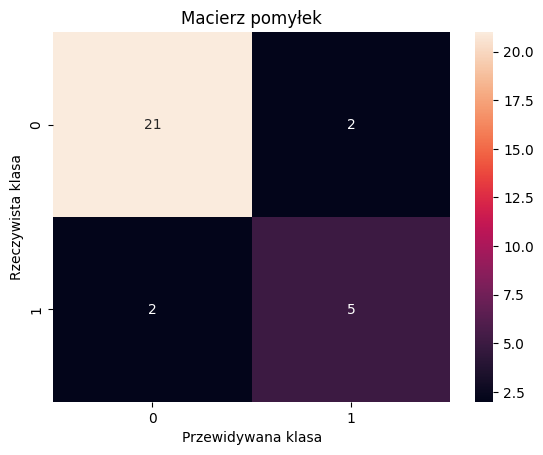

In [201]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_logreg)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Macierz pomyłek')
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

- 21 poprawnie wykrytych tanich zabiegów
- 5 poprawnie wykrytych drogich zabiegów
- 2 tanie błędnie uznane za drogie
- 2 drogie błędie uznane za tanie

Strojenie parametrów

In [202]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_logreg = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'), param_grid, cv=5, scoring='f1')
grid_logreg.fit(X_train, y_train)

print(grid_logreg.best_params_)
print(grid_logreg.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

{'C': 0.1, 'penalty': 'l2'}
0.7342657342657343


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [203]:
print("Ocena po strojeniu\n")
best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg = best_logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best_logreg))
print("Precision:", precision_score(y_test, y_pred_best_logreg, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_best_logreg, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred_best_logreg, average='weighted'))

Ocena po strojeniu

Accuracy: 0.8333333333333334
Precision: 0.8428030303030304
Recall: 0.8333333333333334
F1 score: 0.8370370370370369


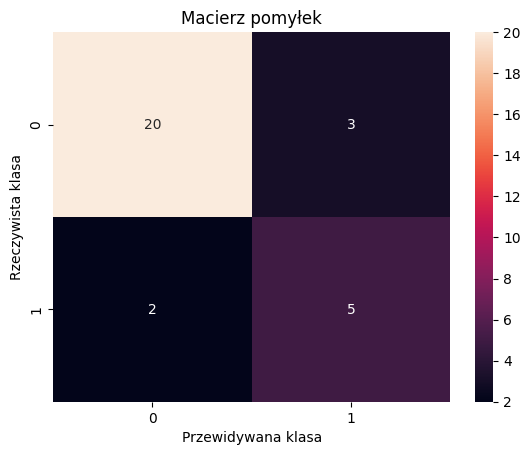

In [204]:
cm_best = confusion_matrix(y_test, y_pred_best_logreg)

sns.heatmap(cm_best, annot=True, fmt='d')
plt.title('Macierz pomyłek')
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

- 20 poprawnie wykrytych tanich zabiegów
- 5 poprawnie wykrytych drogich zabiegów
- 3 tanie błędnie uznane za drogie
- 2 drogie błędnie uznane za tanie

Model po strojeniu nie poprawił wykrywania drogich zabiegów a zaczął częściej oznaczać tanie zabiegi jako drogie. Dlatego wyniki spadły.

Wnioski dotyczące przed i po strojeniu modelu:
- Po strojeniu model wypadł gorzej na zbiorze testowym: Accuracy spadło z 86.7% do 83.3%, F1 spadło z 86.7% do 83.7%
- Najlepsze wyniki osiągnął podstawowy model regresji logistycznej. Strojenie hiperparametrów nie poprawiło jakości klasyfikacji.

## Model - RandomForest

In [205]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)

In [206]:
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Precision:", precision_score(y_test, y_pred_rfc, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rfc, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred_rfc, average='weighted'))

Accuracy: 0.8333333333333334
Precision: 0.8263888888888888
Recall: 0.8333333333333334
F1 score: 0.8286961265684669


In [207]:
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
print(cm_rfc)

[[21  2]
 [ 3  4]]


In [208]:
# strojenie
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rfc = GridSearchCV(RandomForestClassifier(random_state=42,class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

grid_rfc.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [3, 5, 10], 'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [209]:
print(grid_rfc.best_params_)
print(grid_rfc.best_score_)

{'max_depth': 3, 'min_samples_leaf': 4, 'n_estimators': 200}
0.7312820512820513


In [210]:
best_rfc = grid_rfc.best_estimator_
y_pred_best_rfc = best_rfc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best_rfc))
print("Precision:", precision_score(y_test, y_pred_best_rfc, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_best_rfc, average='weighted'))
print("F1 score:", f1_score(y_test, y_pred_best_rfc, average='weighted'))

Accuracy: 0.8333333333333334
Precision: 0.8428030303030304
Recall: 0.8333333333333334
F1 score: 0.8370370370370369


In [211]:
cm_rfc_best = confusion_matrix(y_test, y_pred_best_rfc)
print(cm_rfc_best)

[[20  3]
 [ 2  5]]


In [212]:
importance = pd.DataFrame({
    'Cecha': X_train.columns,
    'Ważność': best_rfc.feature_importances_
})

importance = importance.sort_values(
    'Ważność',
    ascending=False
)

print(importance)

            Cecha       Ważność
0        duration  7.360231e-01
6   gender_samiec  9.090257e-02
5   gender_samica  7.618422e-02
1     species_kot  6.616826e-02
4    species_pies  2.156872e-02
3  species_papuga  9.153037e-03
2  species_królik  6.816795e-08


Wnioski modelu RandomForest:
- Przed strojeniem model wykrył 21 tanich zabiegów, 4 drogie. Accuracy wyniosło 83.3%. F1 - 0.829.
- Po strojeniu hiperparametrów dokładność modelu pozostała na tym samym poziomie 83.3%, jednak poprawie uległa zdolność wykrywania kosztownych zabiegów.
Liczba poprawnie sklasyfikowanych drogich zabiegów wzrosła z 4 do 5 przypadków, co przełożyło się na wzrost wartości F1-score z 0.829 do 0.837.

Wnioski ogólne
- Najlepsze wyniki osiągnęła regresja logistyczna, uzyskując Accuracy oraz F1-score na poziomie 86.7%.
Model Random Forest po strojeniu hiperparametrów poprawił zdolność wykrywania kosztownych zabiegów, czyli liczba poprawnie rozpoznanych przypadków wzrosła z 4 do 5,
jednak nie przełożyło się to na wzrost dokładności klasyfikacji. Ostatecznie za najlepszy model klasyfikacyjny uznano regresję logistyczną ze względu na najwyższą skuteczność oraz prostotę interpretacji wyników.

## Weryfikacja klasyfikacji wybranych przypadków
W tej części analizowane są wyniki klasyfikacji dla poszczególnych zabiegów znajdujących się w zbiorze testowym. Oprócz przewidzianej klasy prezentowane są również dodatkowe informacje, takie jak nazwa zabiegu, gatunek zwierzęcia, koszt oraz rzeczywista klasa. Pozwala to ocenić, które przypadki zostały sklasyfikowane poprawnie, a które stanowiły największe wyzwanie dla modelu.

In [213]:
wyniki = X_test.copy()

wyniki['Rzeczywista klasa'] = y_test.values
wyniki['Przewidziana klasa'] = y_pred_logreg

In [214]:
df_ml = df_ml.rename(columns={
    'name_x': 'pet_name',
    'name_y': 'treatment_name'
})

In [215]:
info = df_ml[['pet_name','treatment_name', 'species','duration','cost']]

In [216]:
info.head()

,pet_name,treatment_name,species,duration,cost
0,Rex,szczepienie,pies,40.0,50.0
1,Mruczek,alergia,kot,30.0,40.0
2,Bella,kontrola,pies,60.0,30.0
3,Kropka,uraz łapy,kot,90.0,90.0
4,Kruszynka,operacja,chomik,120.0,150.0


In [217]:
X_train, X_test, y_train, y_test, info_train, info_test = train_test_split(
    X,
    y,
    info,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [218]:
# po predykcji
wyniki = info_test.copy()

wyniki['Rzeczywista klasa'] = y_test.values
wyniki['Przewidziana klasa'] = y_pred_logreg

wyniki.head(10)

,pet_name,treatment_name,species,duration,cost,Rzeczywista klasa,Przewidziana klasa
95,Wróbel,dermatologia,pies,25.0,50.0,0,0
117,Rex,diagnostyka,pies,35.0,95.0,0,0
152,Rufi,badanie ogólne,pies,20.0,50.0,0,0
145,Bajka,dermatologia,pies,25.0,50.0,0,0
33,Ruda,kontrola,kot,20.0,40.0,0,0
140,Baśka,badanie ogólne,pies,30.0,60.0,0,0
20,Śnieżka,badanie ogólne,królik,30.0,60.0,0,0
79,Fado,kardiologia,pies,35.0,110.0,1,0
128,Śnieżka,kontrola,królik,20.0,40.0,0,0
86,Kleopatra,ortopedia,kot,35.0,90.0,0,0


In [219]:
# tylko błędy modelu
wyniki_bledy = wyniki[wyniki['Rzeczywista klasa'] != wyniki['Przewidziana klasa']]
wyniki_bledy

,pet_name,treatment_name,species,duration,cost,Rzeczywista klasa,Przewidziana klasa
79,Fado,kardiologia,pies,35.0,110.0,1,0
31,Złotko,dermatologia,chomik,50.0,100.0,0,1
83,Zara,kardiologia,pies,35.0,110.0,1,0
2,Bella,kontrola,pies,60.0,30.0,0,1


## Eksperyment: zastosowanie metody SMOTE
Technika ta generuje sztuczne przykłady dla klasy mniejszościowej na podstawie istniejących obserwacji, dzięki czemu liczebność obu klas zostaje wyrównana.

Celem eksperymentu jest sprawdzenie, czy zrównoważenie klas przy pomocy SMOTE poprawi skuteczność klasyfikacji kosztownych zabiegów. Wyniki modelu po zastosowaniu SMOTE zostaną porównane z wynikami uzyskanymi na oryginalnym zbiorze danych.

In [220]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [221]:
# przed
print(y_train.value_counts())

high_cost
0    91
1    26
Name: count, dtype: int64


In [222]:
# po
print(y_train_smote.value_counts())

high_cost
0    91
1    91
Name: count, dtype: int64


In [223]:
from sklearn.linear_model import LogisticRegression

logreg_smote = LogisticRegression(
    class_weight=None,
    random_state=42,
    max_iter=1000
)

logreg_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = logreg_smote.predict(X_test)

In [224]:
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_smote, average='weighted'))
print("F1:", f1_score(y_test, y_pred_smote, average='weighted'))

Accuracy: 0.8333333333333334
Precision: 0.8428030303030304
Recall: 0.8333333333333334
F1: 0.8370370370370369


Text(50.722222222222214, 0.5, 'Rzeczywista klasa')

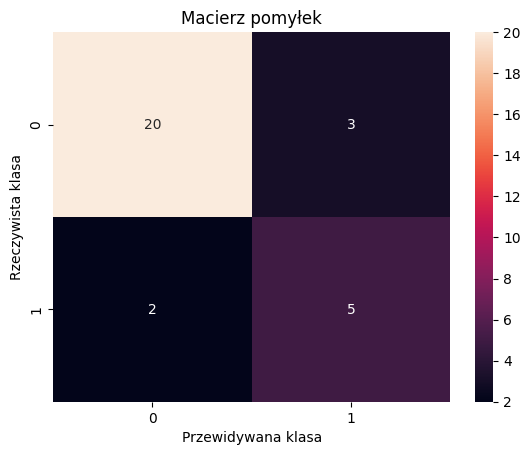

In [225]:
cm = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Macierz pomyłek')
plt.xlabel('Przewidywana klasa')
plt.ylabel('Rzeczywista klasa')

Po zastosowaniu SMOTE i ponownym wytrenowaniu modelu nie zaobserwowano istotnej poprawy jakości klasyfikacji. Wartości Accuracy, Precision, Recall oraz F1-score pozostały na bardzo podobnym poziomie jak przed zastosowaniem tej techniki. Oznacza to, że umiarkowana nierównowaga klas występująca w analizowanym zbiorze nie miała znaczącego wpływu na działanie modelu.


## Predykcja dla nowych przypadków

In [226]:
# drogi zabieg - czas 90 min
nowy_rekord = pd.DataFrame({'duration':[90], 'species':['pies'], 'gender':['samiec']})

In [227]:
nowy_rekord = pd.get_dummies(nowy_rekord, columns=['species', 'gender'], drop_first=True)

In [228]:
# dopasowanie kolumn
nowy_rekord = nowy_rekord.reindex(columns=X_train.columns, fill_value=0)

In [229]:
# predykcja dla klasy
predykcja = logreg_smote.predict(nowy_rekord)
print(predykcja) # - prawpodobieństwo, klasa 1

[1]


In [230]:
# Prawdopodobieństwo
logreg.predict_proba(nowy_rekord)
# klasa: 0-0.0066%; 1-99.99934%

array([[6.55939600e-05, 9.99934406e-01]])

In [231]:
pred = logreg.predict(nowy_rekord)[0]
prob = logreg.predict_proba(nowy_rekord)[0,1]

print("Przewidywana klasa:", pred)
print(f"Prawdopodobieństwo drogiego zabiegu: {prob:.2%}")

Przewidywana klasa: 1
Prawdopodobieństwo drogiego zabiegu: 99.99%


In [232]:
# tanie zabieg, czas 10 min
tani_nowy = pd.DataFrame({
    'duration': [10],
    'species': ['kot'],
    'gender': ['samica']
})

In [233]:
tani_nowy = pd.get_dummies(tani_nowy, columns=['species', 'gender'], drop_first=True)

In [234]:
tani_nowy = tani_nowy.reindex(columns=X_train.columns, fill_value=0)

In [235]:
pred_tani = logreg.predict(tani_nowy)[0]

prob_tani = logreg.predict_proba(tani_nowy)[0]

print("Przewidywana klasa:", pred_tani)
print(f"Prawdopodobieństwo taniego zabiegu:",(prob_tani[0]))

Przewidywana klasa: 0
Prawdopodobieństwo taniego zabiegu: 0.9941910745580775


W celu sprawdzenia działania modelu przygotowano przykładowe rekordy opisujące nowe przypadki pacjentów. Model poprawnie przypisał klasy "tani zabieg" oraz "drogi zabieg" na podstawie dostępnych cech, takich jak gatunek zwierzęcia, płeć oraz przewidywany czas trwania zabiegu. Dla każdego przypadku wyznaczono również prawdopodobieństwo przynależności do danej klasy, co pozwala ocenić pewność predykcji.

Analiza wykazała, że wraz ze wzrostem czasu trwania zabiegu rośnie prawdopodobieństwo zaklasyfikowania go jako kosztowny.

## ROC, AUC - regresja logistyczna

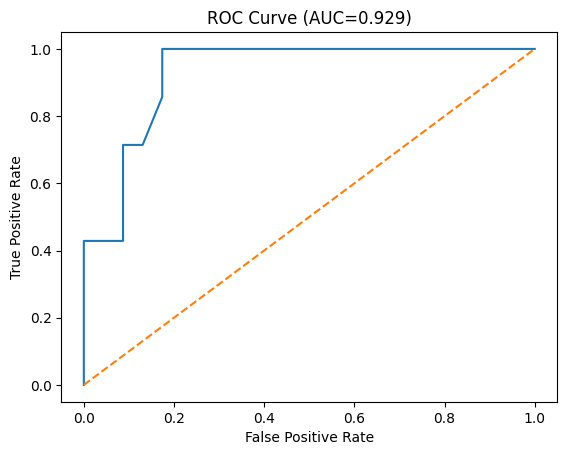

In [236]:
from sklearn.metrics import roc_curve, auc

y_prob = logreg.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f'ROC Curve (AUC={roc_auc:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

W celu dodatkowej oceny jakości klasyfikatora wyznaczono krzywą ROC oraz współczynnik AUC. Uzyskana wartość AUC wyniosła 0.929, co świadczy o bardzo dobrej zdolności modelu do rozróżniania kosztownych i niekosztownych zabiegów. Krzywa ROC przebiega blisko lewego górnego rogu wykresu, co oznacza wysoką skuteczność wykrywania kosztownych zabiegów przy jednoczesnym utrzymaniu niskiej liczby błędnych klasyfikacji.